/tmp/ipykernel_29026/2589945095.py:21: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  uncertainties = np.array([scipy.stats.sem(data_by_voltage[v]) for v in voltages])


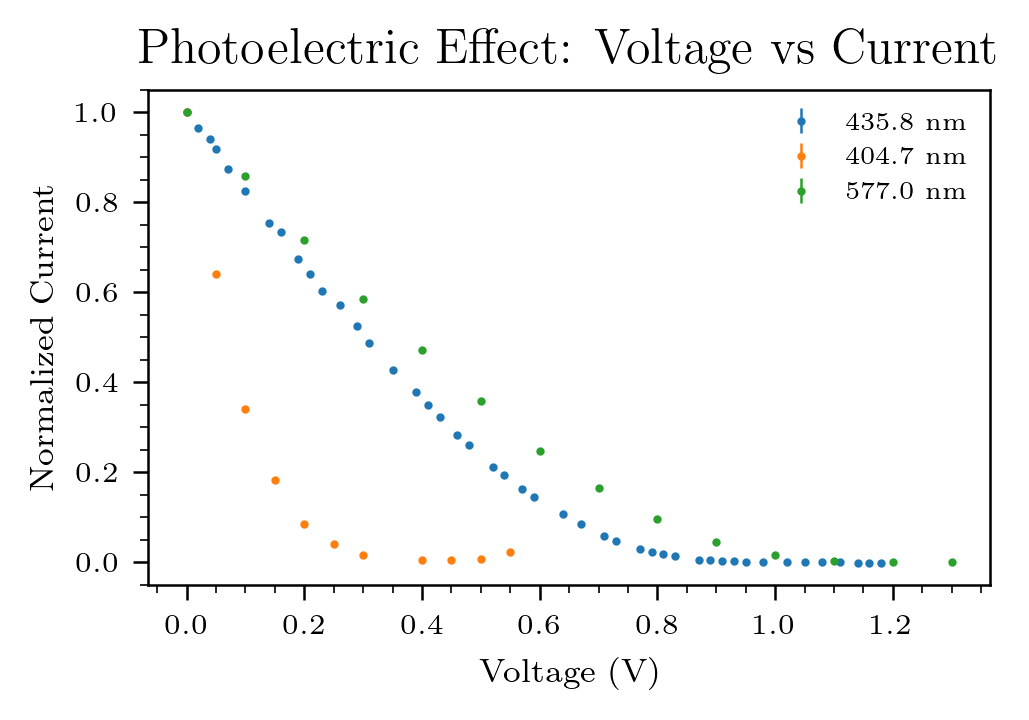

In [110]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import csv

plt.style.use("../jlab.mplstyle")

def load_iv_data(filename):
    """Load a voltage/current CSV, merging repeated voltages into mean ± SEM.
    Uses the first two columns regardless of header names."""
    data_by_voltage = {}
    with open(filename, newline="") as f:
        reader = csv.reader(f)
        next(reader)  # skip header
        for row in reader:
            v, i = float(row[0]), float(row[1])
            data_by_voltage.setdefault(v, []).append(i)

    voltages = np.array(sorted(data_by_voltage.keys()))
    currents = np.array([np.mean(data_by_voltage[v]) for v in voltages])
    uncertainties = np.array([scipy.stats.sem(data_by_voltage[v]) for v in voltages])
    return voltages, currents, uncertainties

datasets = {
    "435.8 nm": load_iv_data("435.8.csv"),
    "404.7 nm": load_iv_data("404.7.csv"),
    "577.0 nm": load_iv_data("577.0.csv"),
}

# Normalize currents and uncertainties to fraction of each dataset's max current
datasets = {
    label: (v, i / i.max(), u / i.max())
    for label, (v, i, u) in datasets.items()
}

# Plot voltage vs current with errorbars
fig, ax = plt.subplots(figsize=(3.5, 2.5))
for label, (voltages, currents, uncertainties) in datasets.items():
    ax.errorbar(voltages, currents, yerr=uncertainties, fmt="o", capsize=0,
                markersize=1, label=label)
ax.set_xlabel("Voltage (V)")
ax.set_ylabel("Normalized Current")
ax.set_title("Photoelectric Effect: Voltage vs Current")
ax.legend()
plt.tight_layout()
plt.show()


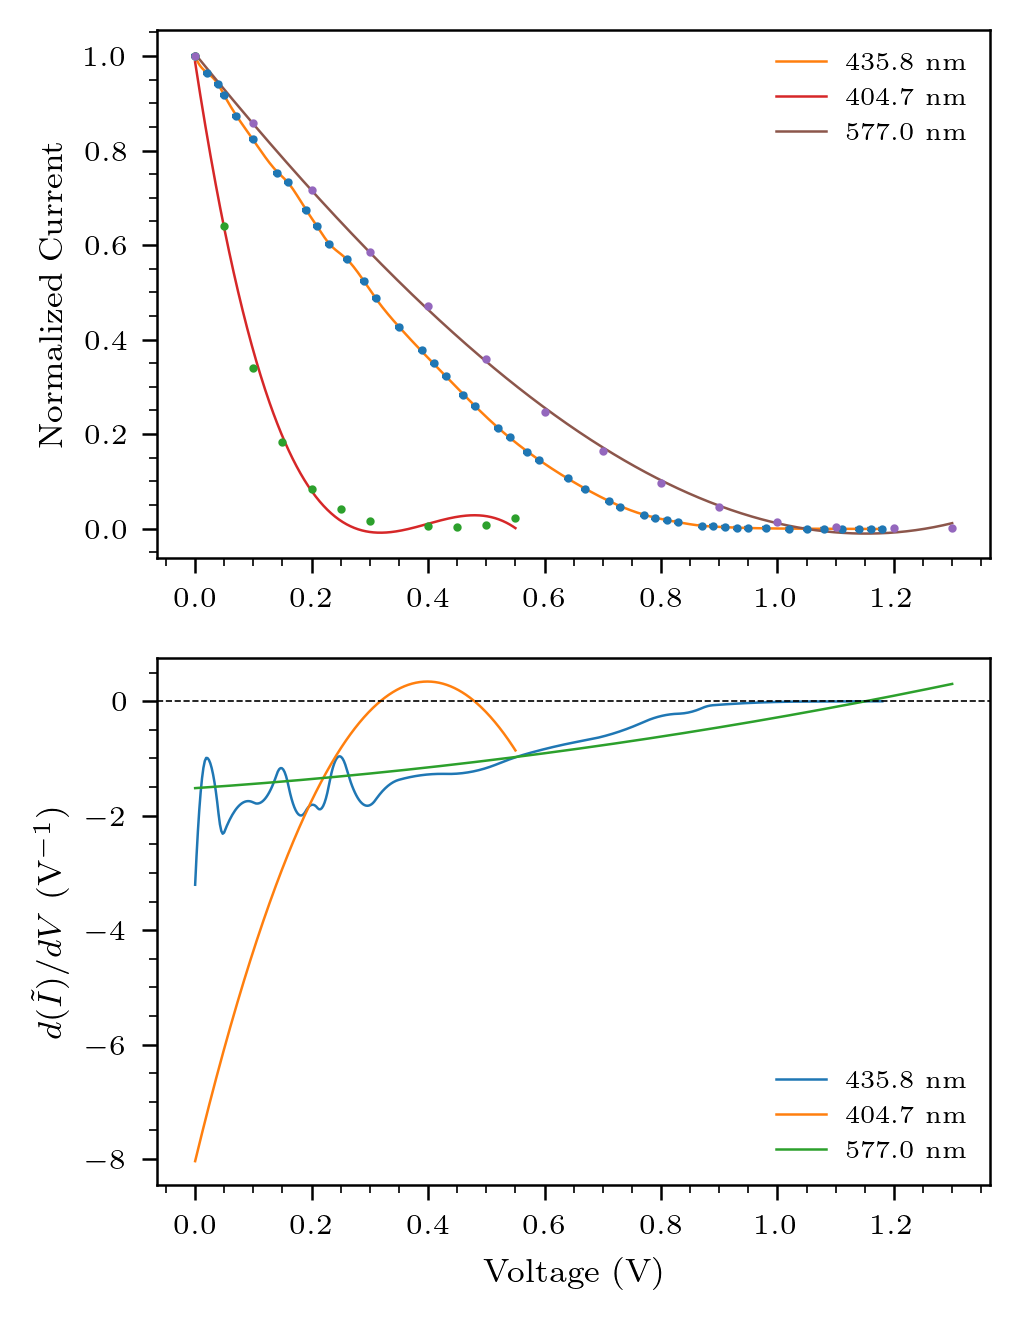

In [111]:
from scipy.interpolate import UnivariateSpline

smoothing = 10000

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=False, figsize=(3.5, 4.5))

for label, (voltages, currents, uncertainties) in datasets.items():
    w = np.where(uncertainties > 0, 1 / uncertainties, 1.0)

    us = UnivariateSpline(voltages, currents, w=w, k=3, s=smoothing)
    us_deriv = us.derivative()

    v_fine = np.linspace(voltages[0], voltages[-1], 500)

    ax1.errorbar(voltages, currents, yerr=uncertainties, fmt="o", markersize=1)
    ax1.plot(v_fine, us(v_fine), label=label)

    ax2.plot(v_fine, us_deriv(v_fine), label=label)

ax2.axhline(0, color="k", linewidth=0.4, linestyle="--")

ax1.set_ylabel("Normalized Current")
ax1.legend()

ax2.set_xlabel("Voltage (V)")
ax2.set_ylabel(r"$d(\tilde{I})/dV$ (V$^{-1}$)")
ax2.legend()

plt.tight_layout()
plt.show()
